### Nhập thư viện 

In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


### Đọc dataset 

In [38]:
data = pd.read_csv("data.csv",delimiter=';')
print("Kích thước dữ liệu:", data.shape)
data.info()
data.describe().T
data = data.dropna()

Kích thước dữ liệu: (871, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 871 entries, 0 to 870
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   AnimalName  871 non-null    object
 1   symptoms1   871 non-null    object
 2   symptoms2   871 non-null    object
 3   symptoms3   871 non-null    object
 4   symptoms4   871 non-null    object
 5   symptoms5   871 non-null    object
 6   Dangerous   869 non-null    object
dtypes: object(7)
memory usage: 47.8+ KB


### 5 dòng đầu của dữ liệu 

In [39]:
data.head()

,AnimalName,symptoms1,symptoms2,symptoms3,symptoms4,symptoms5,Dangerous
0,Dog,Fever,Diarrhea,Vomiting,Weight loss,Dehydration,Yes
1,Dog,Fever,Diarrhea,Coughing,Tiredness,Pains,Yes
2,Dog,Fever,Diarrhea,Coughing,Vomiting,Anorexia,Yes
3,Dog,Fever,Difficulty breathing,Coughing,Lethargy,Sneezing,Yes
4,Dog,Fever,Diarrhea,Coughing,Lethargy,Blue Eye,Yes


### Chia tập train và tập test 

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### ColumnTransformer: OneHotEncoder cho tất cả features object

In [41]:
categorical_cols = X.columns.tolist()
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

### Pipeline: preprocessing + SVM

In [42]:
pipe = Pipeline([
    ('preprocess', preprocess),
    ('svm', SVC())
])

### Tham số cho RandomizedSearchCV

In [43]:
param_dist = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.001],
    'svm__kernel': ['rbf', 'poly', 'linear']
}

### RandomizedSearchCV: tìm tham số tốt nhất

In [44]:
grid = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=10,      # số cấu hình thử
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)


### Xây dựng mô hình 

In [45]:
# Train model 
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

# Predict trên test
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

Best parameters: {'svm__kernel': 'linear', 'svm__gamma': 'scale', 'svm__C': 10}
Best CV Accuracy: 0.9870503597122303


c:\Users\dvt\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### Đánh giá mô hình 

In [46]:
print("\nAccuracy on test set:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy on test set: 1.0

Classification Report:
               precision    recall  f1-score   support

          No       1.00      1.00      1.00         4
         Yes       1.00      1.00      1.00       170

    accuracy                           1.00       174
   macro avg       1.00      1.00      1.00       174
weighted avg       1.00      1.00      1.00       174



### Vẽ Confusion Matrix bằng seaborn

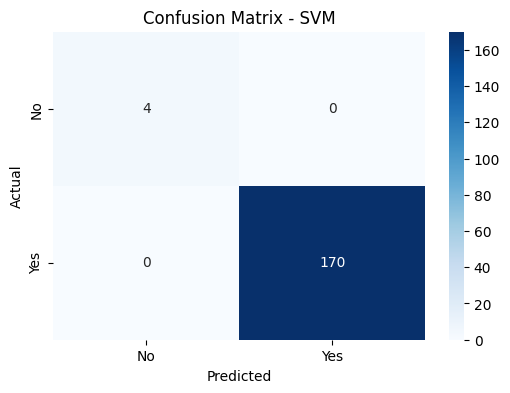

In [47]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No", "Yes"],
            yticklabels=["No", "Yes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()

### nhận xét quan trọng

### Dataset quá nhỏ hoặc quá đơn giản
- Chỉ 4 mẫu `No` trong test → dễ dàng dự đoán chính xác, mô hình có thể **overfitting** với nhãn `No`.
- Nhiều khả năng tập train đã chứa đủ mẫu đặc trưng, nên **SVM có thể phân loại dễ dàng**.

### Số lượng nhãn lệch
- `No:Yes = 4:170` → dataset **rất imbalanced**.
- Accuracy cao nhưng không phản ánh **khả năng tổng thể của mô hình với nhãn ít (`No`)**.
- Trong thực tế, nên dùng metrics khác như **balanced accuracy**, **roc_auc**, hoặc **oversampling nhãn ít**.

### Support nhỏ cho `No`
- Khi support quá nhỏ (4 mẫu), các chỉ số **precision/recall/f1-score cho `No` không đáng tin lắm**.

---

### 🔹 Gợi ý cải thiện

### 1️⃣ Kiểm tra imbalance nhãn
```python
print(y_train.value_counts())
print(y_test.value_counts())


### Kết thúc 